<a href="https://colab.research.google.com/github/Yuvaraj-3604/colab_project/blob/main/Cardiovascular_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('cardio_train (1).csv', sep=';')

Saving cardio_train (1).csv to cardio_train (1).csv


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [ ]:
df.shape

(70000, 13)

In [ ]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df['age'] = (df['age']/365).astype(int)

In [ ]:
df['BMI'] = df['weight'] / ((df['height']/100)**2)

In [ ]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,52.840671,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700,27.556513
std,28851.302323,6.766774,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003,6.091511
min,0.000000,29.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.471784
25%,25006.750000,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,23.875115
50%,50001.500000,53.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,26.374068
75%,74889.250000,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,30.222222
max,99999.000000,64.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,298.666667


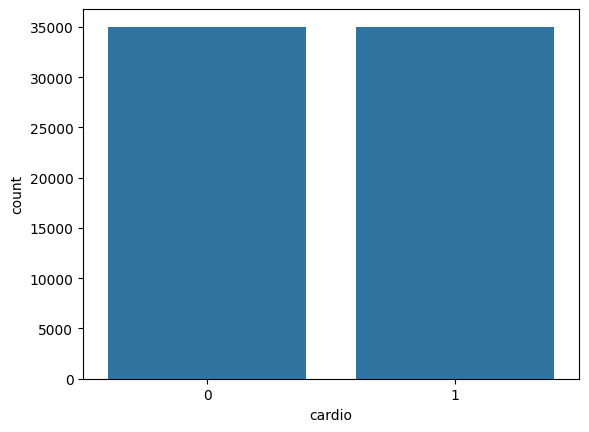

In [ ]:
sns.countplot(x='cardio', data=df)
plt.show()

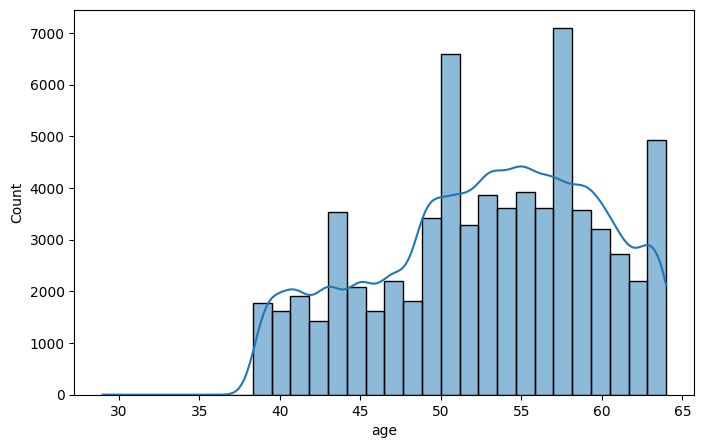

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.show()

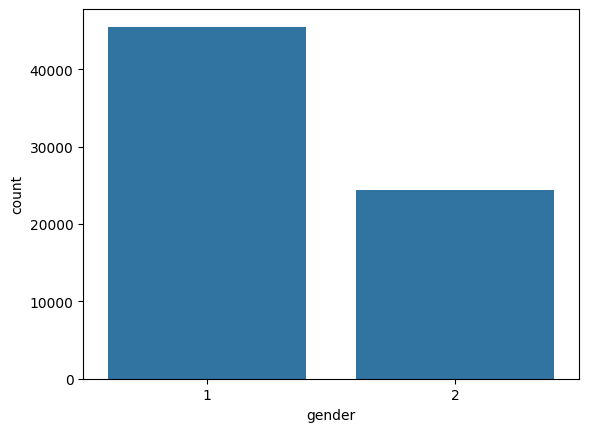

In [ ]:
sns.countplot(x='gender', data=df)
plt.show()

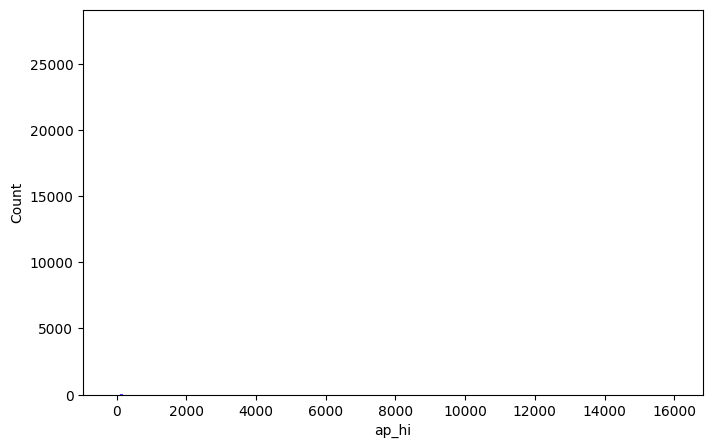

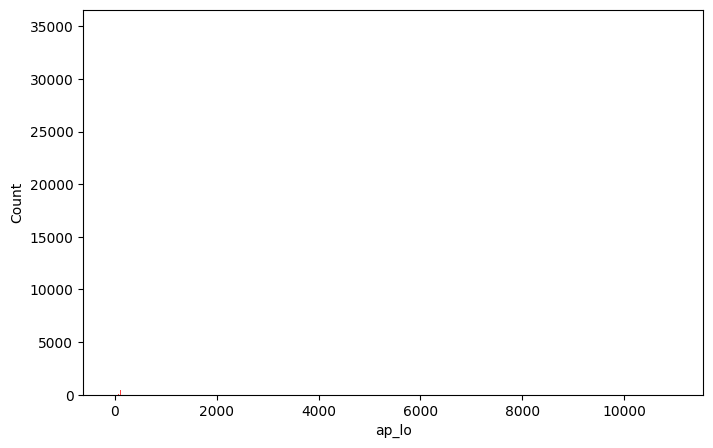

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['ap_hi'], color='blue')
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['ap_lo'], color='red')
plt.show()

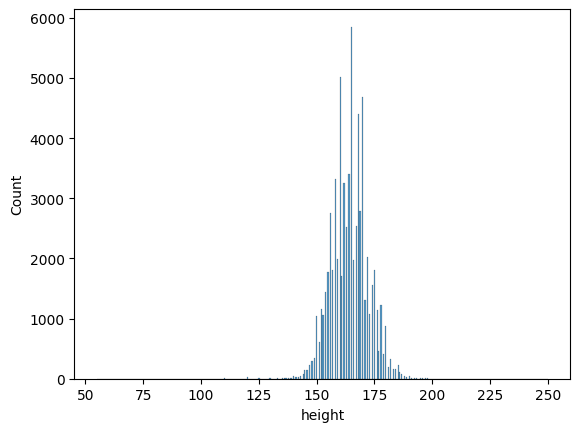

In [ ]:
sns.histplot(df['height'])
plt.show()

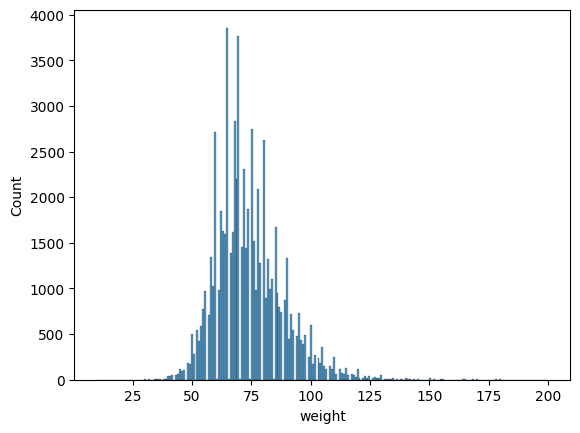

In [ ]:
sns.histplot(df['weight'])
plt.show()

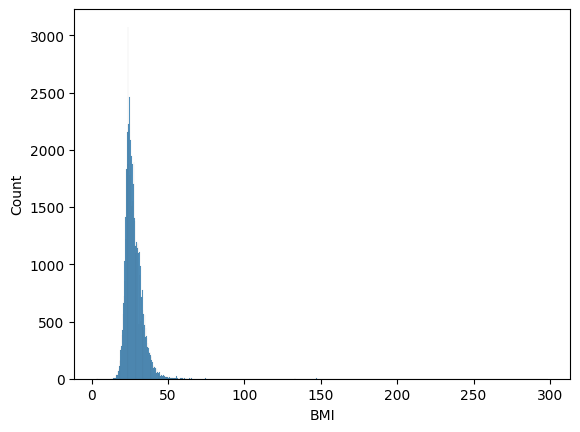

In [ ]:
sns.histplot(df['BMI'])
plt.show()

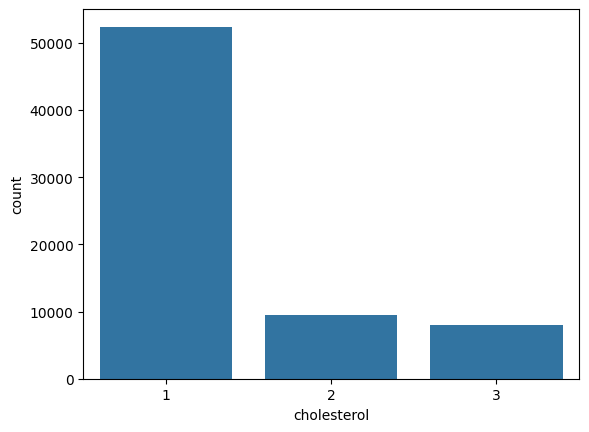

In [ ]:
sns.countplot(x='cholesterol', data=df)
plt.show()

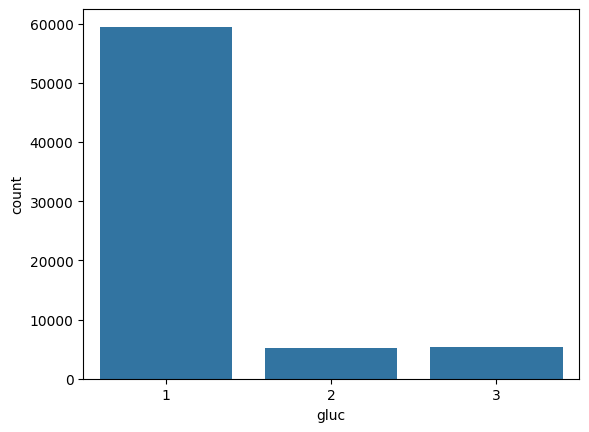

In [ ]:
sns.countplot(x='gluc', data=df)
plt.show()

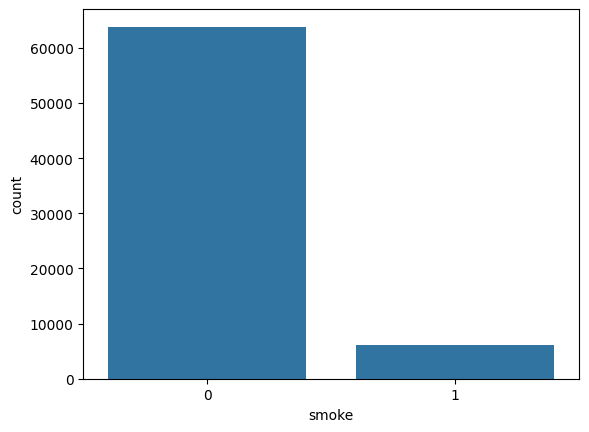

In [ ]:
sns.countplot(x='smoke', data=df)
plt.show()

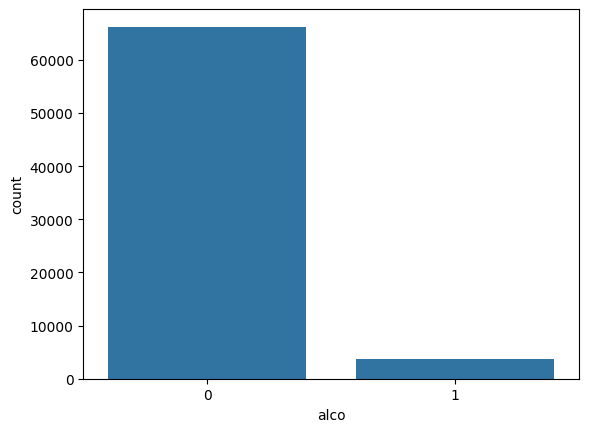

In [ ]:
sns.countplot(x='alco', data=df)
plt.show()

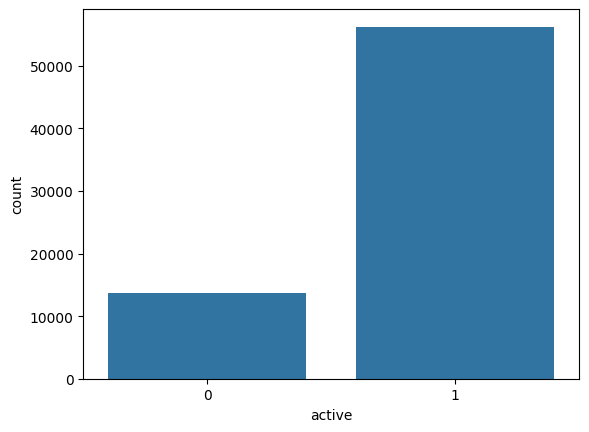

In [ ]:
sns.countplot(x='active', data=df)
plt.show()

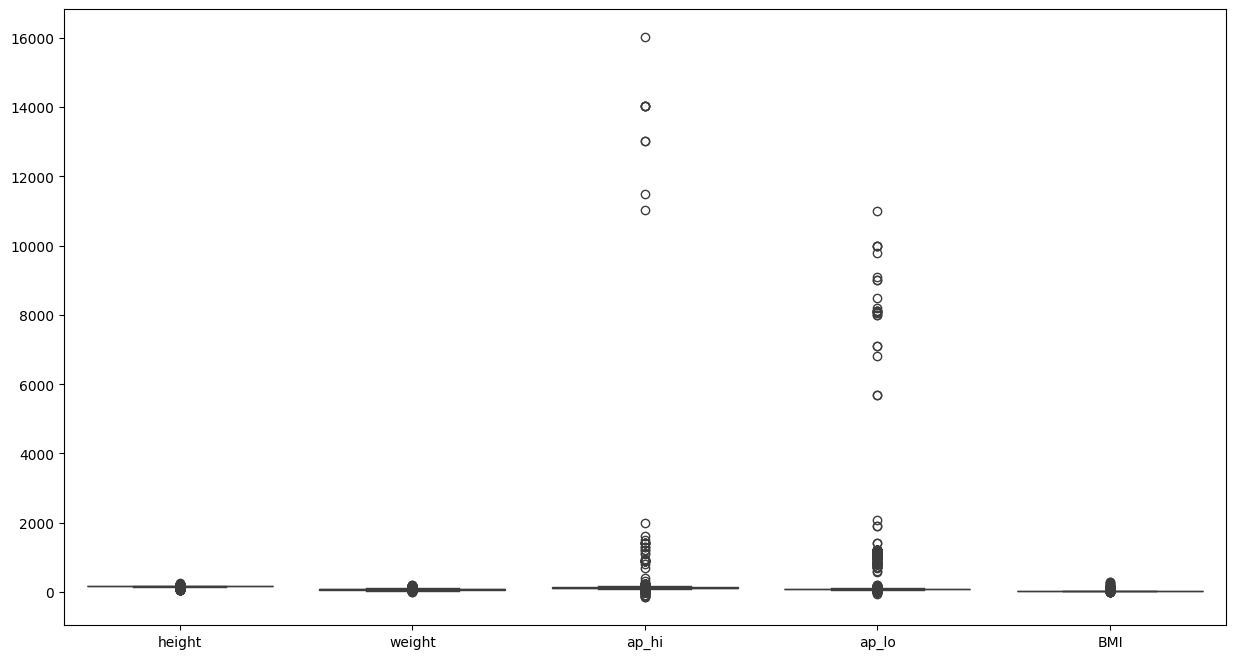

In [ ]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df[['height','weight','ap_hi','ap_lo','BMI']])

plt.show()

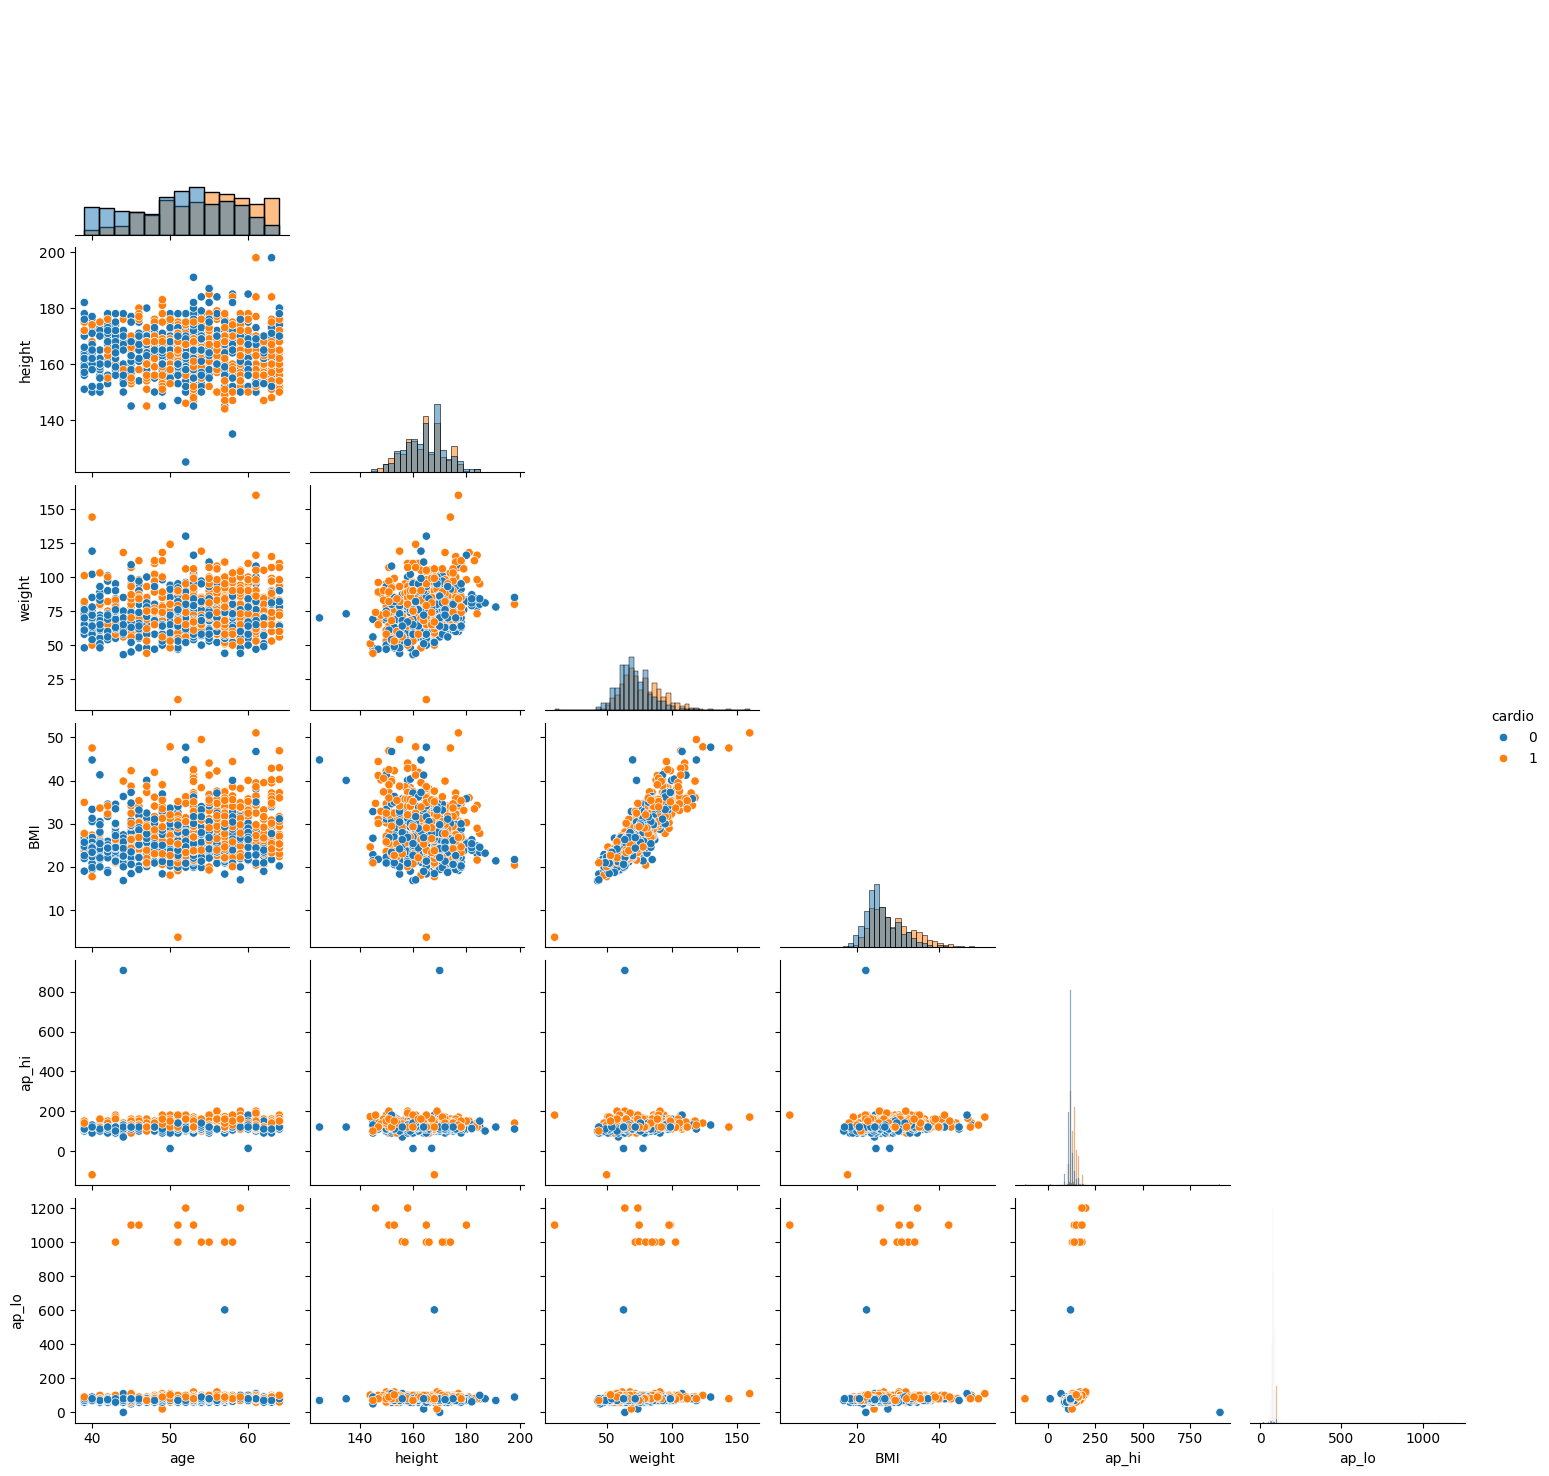

In [ ]:
sample_df = df.sample(1000, random_state=42)

sns.pairplot(
    sample_df[['age','height','weight','BMI','ap_hi','ap_lo','cardio']],
    hue='cardio',
    corner=True,
    diag_kind='hist'
)

plt.show()

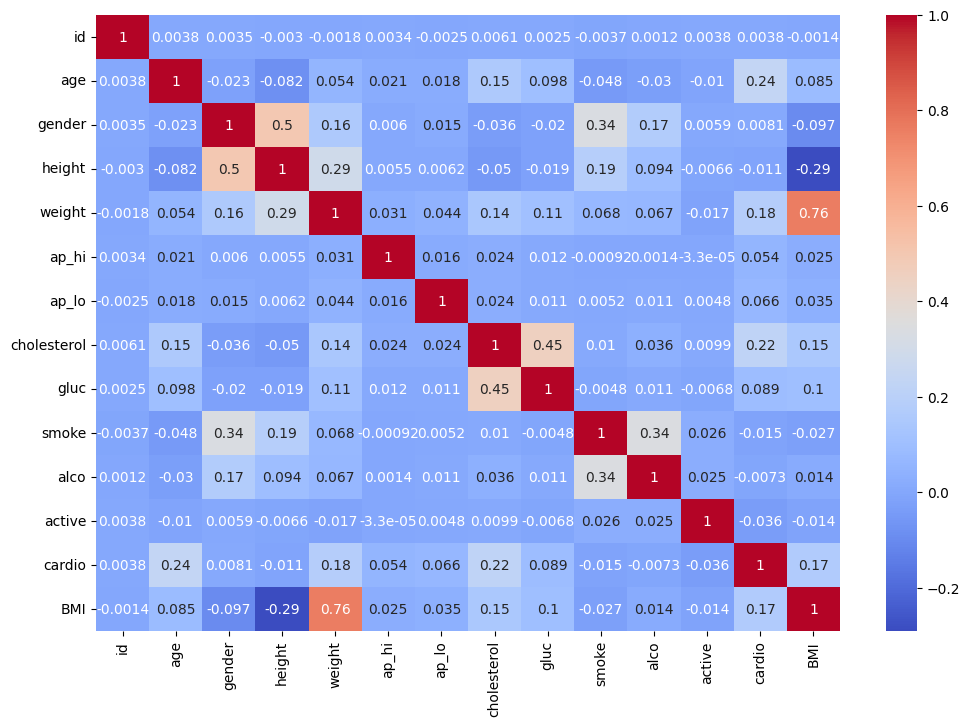

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.show()

In [ ]:
df = df.drop('id', axis=1)

In [ ]:
X = df.drop('cardio', axis=1)

y = df['cardio']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_lr))

Accuracy: 0.7232857142857143


In [ ]:
knn = KNeighborsClassifier()

knn.fit(X_train,y_train)

pred_knn = knn.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_knn))

Accuracy: 0.6470714285714285


In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_dt))

Accuracy: 0.6383571428571428


In [ ]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_rf))

Accuracy: 0.7090714285714286


In [43]:
svm = SVC()

svm.fit(X_train,y_train)

pred_svm = svm.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_svm))

Accuracy: 0.7335714285714285


In [44]:
results = pd.DataFrame({

'Model':['Logistic Regression',
         'KNN',
         'Decision Tree',
         'Random Forest',
         'SVM'],

'Accuracy':[

accuracy_score(y_test,pred_lr),

accuracy_score(y_test,pred_knn),

accuracy_score(y_test,pred_dt),

accuracy_score(y_test,pred_rf),

accuracy_score(y_test,pred_svm)

]

})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.723286
1                  KNN  0.647071
2        Decision Tree  0.638357
3        Random Forest  0.709071
4                  SVM  0.733571


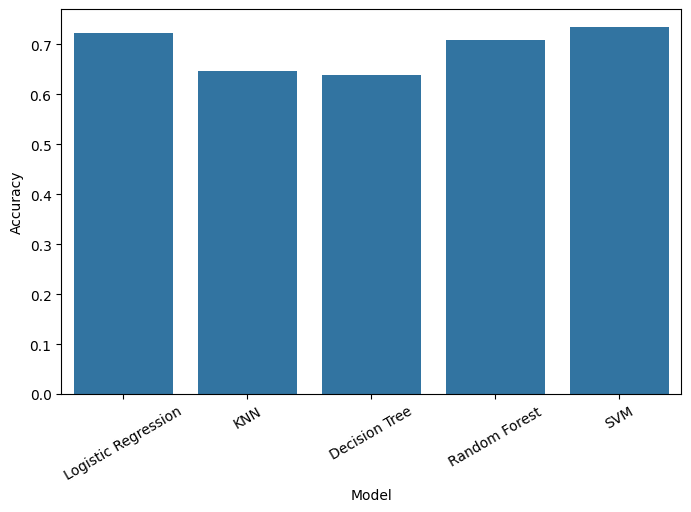

In [45]:
plt.figure(figsize=(8,5))

sns.barplot(x='Model', y='Accuracy', data=results)

plt.xticks(rotation=30)

plt.show()

In [46]:
best_model = rf

prediction = best_model.predict(X_test)

print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       0.71      0.71      0.71      6988
           1       0.71      0.70      0.71      7012

    accuracy                           0.71     14000
   macro avg       0.71      0.71      0.71     14000
weighted avg       0.71      0.71      0.71     14000

